# Identify Good Headliner Animation Window 

In this file, we are seeking out a spot in our data which can effectively communicate the idea of weather-related vehicle collisions in Connecticut. We want a window with precipitation and quite a few crashes

Loading weather CSVs …


/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1584563439.py:57: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["time"] = pd.to_datetime(df["time"], infer_datetime_format=True)
/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1584563439.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("date", group_keys=False).apply(daily_delta)
/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1584563439.py:57: UserWarning: The argu

  Loaded 220 station files  |  86,782,080 hourly rows
  Hourly weather rows (2015+): 78,888
Loading crash data …


/var/folders/lt/90cmmvp91vn9qgdwpxyyb6l40000gn/T/ipykernel_82025/1584563439.py:112: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  crash["crash_dt"] = pd.to_datetime(


  Crash date range: 2013-07-15 → 2026-01-30
Scoring 72-hour windows …

── Top 10 candidate 72-hour storm windows ──────────────────────────────
       window_start          window_end  precip_sum_mm  total_crashes    score
2021-09-01 06:00:00 2021-09-04 05:00:00       0.137476            304 0.914966
2021-09-01 07:00:00 2021-09-04 06:00:00       0.137476            303 0.913265
2021-09-01 05:00:00 2021-09-04 04:00:00       0.137476            301 0.909864
2021-09-01 04:00:00 2021-09-04 03:00:00       0.137476            300 0.908163
2021-09-01 08:00:00 2021-09-04 07:00:00       0.137476            298 0.904762
2021-09-01 03:00:00 2021-09-04 02:00:00       0.137476            296 0.901361
2021-09-01 09:00:00 2021-09-04 08:00:00       0.137476            296 0.901361
2021-09-01 02:00:00 2021-09-04 01:00:00       0.137476            295 0.899660
2021-09-01 11:00:00 2021-09-04 10:00:00       0.137461            295 0.899605
2021-09-01 10:00:00 2021-09-04 09:00:00       0.137476            

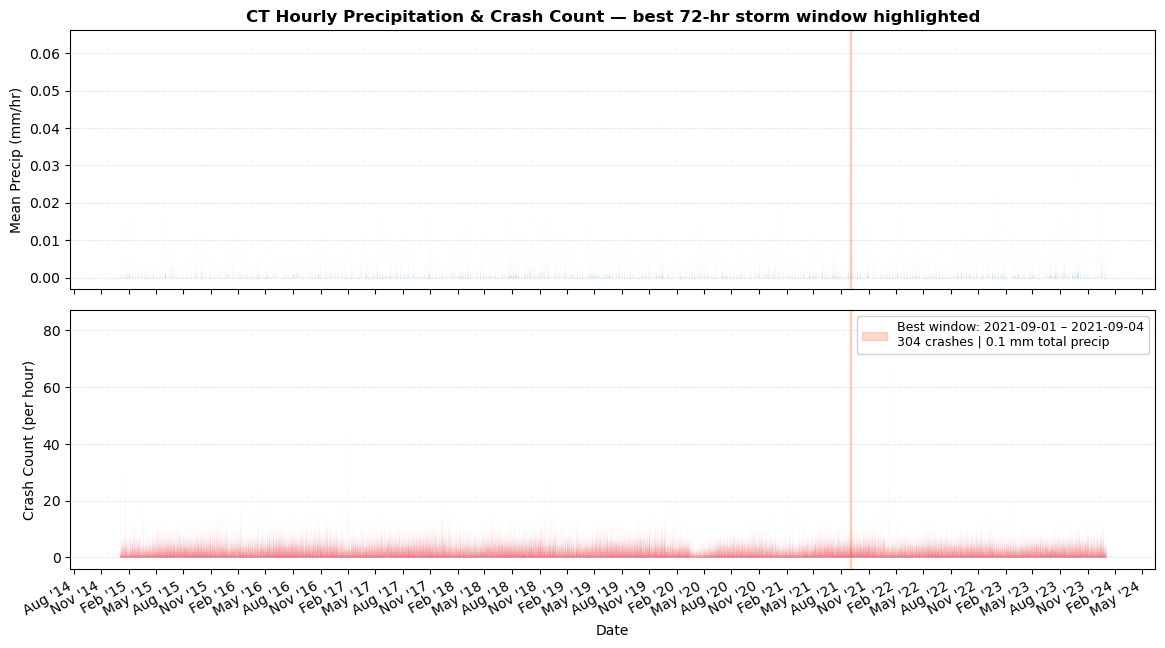


╔══════════════════════════════════════════════════════════════════╗
║  RECOMMENDED 72-HOUR WINDOW                                      ║
║  Start : 2021-09-01 06:00:00                              ║
║  End   : 2021-09-04 05:00:00                              ║
║  Crashes:   304   |   Mean precip: 0.14 mm total     ║
╚══════════════════════════════════════════════════════════════════╝

→ Pass these timestamps to ct_precip_crash_animation.py



In [2]:
"""
find_storm_window.py
────────────────────
Scans crash data + hourly weather data to find the best 72-hour window
where:  (a) precipitation across CT is high, and
        (b) crash count is elevated.

Outputs a ranked table of candidate windows + a quick diagnostic plot.

Usage:
    python find_storm_window.py

Edit the PATHS section below to match your local directory layout.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ──────────────────────────────────────────────────────────────────────────────
# PATHS  ← edit these
# ──────────────────────────────────────────────────────────────────────────────
WEATHER_DIR  = "/Volumes/JB_Fortress_L3/college_work/EEC/merged_csvs/"
CRASH_CSV    = (
    "/Users/jackbienvenuejr/Desktop/Desktop - jack-bienvenue/Spring2026Classes/"
    "STAT5605/STAT5605_AppliedStatII_Spring2026/course_project/data/"
    "clean_crash_data/crash_data_weather.csv"
)
OUT_DIR      = "storm_finder_output"   # created next to this script
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(OUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# 1.  LOAD & AGGREGATE WEATHER  →  hourly mean precipitation across all CT stations
# ══════════════════════════════════════════════════════════════════════════════
print("Loading weather CSVs …")

weather_files = glob.glob(os.path.join(WEATHER_DIR, "*.csv"))
if not weather_files:
    raise FileNotFoundError(f"No CSVs found in {WEATHER_DIR}")

all_hourly = []

for fp in weather_files:
    try:
        df = pd.read_csv(fp)
        # Normalise column names to lower-case
        df.columns = df.columns.str.strip().str.lower()

        # Parse time  (format seen in your notebook: "1/1/79 0:00")
        if "time" not in df.columns:
            continue
        df["time"] = pd.to_datetime(df["time"], infer_datetime_format=True)

        if "tp" not in df.columns:
            continue

        # ── Reconstruct hourly precipitation from cumulative daily field ──
        # tp resets each calendar day; at midnight, the value IS the first hour.
        # For every subsequent hour subtract the previous hour's cumulative value.
        df = df.sort_values("time").copy()
        df["date"] = df["time"].dt.date

        def daily_delta(grp):
            grp = grp.sort_values("time").copy()
            grp["precip_hr"] = grp["tp"].diff().clip(lower=0)
            # First observation of each day: use the raw tp value directly
            grp.loc[grp.index[0], "precip_hr"] = grp["tp"].iloc[0]
            return grp

        df = df.groupby("date", group_keys=False).apply(daily_delta)
        df["precip_hr"] = df["precip_hr"].fillna(0).clip(lower=0)

        # Keep only columns we need
        all_hourly.append(df[["time", "latitude", "longitude", "precip_hr"]])

    except Exception as e:
        print(f"  ⚠ Skipped {os.path.basename(fp)}: {e}")

if not all_hourly:
    raise RuntimeError("Could not parse any weather files.")

weather = pd.concat(all_hourly, ignore_index=True)
print(f"  Loaded {len(all_hourly)} station files  |  {len(weather):,} hourly rows")

# Mean precip across all stations per hour
hourly_precip = (
    weather.groupby("time")["precip_hr"]
    .mean()
    .rename("mean_precip_mm")
    .reset_index()
    .sort_values("time")
)

# Filter to crash-data era (2015 onward)
hourly_precip = hourly_precip[hourly_precip["time"].dt.year >= 2015].copy()
print(f"  Hourly weather rows (2015+): {len(hourly_precip):,}")

# ══════════════════════════════════════════════════════════════════════════════
# 2.  LOAD CRASH DATA  →  hourly crash counts
# ══════════════════════════════════════════════════════════════════════════════
print("Loading crash data …")

crash = pd.read_csv(CRASH_CSV)
crash.columns = crash.columns.str.strip()

# Build a datetime column from "Date Of Crash" + "Hour of the Day"
crash["crash_dt"] = pd.to_datetime(
    crash["Date Of Crash"].astype(str), infer_datetime_format=True
) + pd.to_timedelta(crash["Hour of the Day"].astype(int), unit="h")

# Hourly crash counts
hourly_crashes = (
    crash.groupby("crash_dt")
    .size()
    .rename("crash_count")
    .reset_index()
    .rename(columns={"crash_dt": "time"})
)
print(f"  Crash date range: {crash['crash_dt'].min().date()} → {crash['crash_dt'].max().date()}")

# ══════════════════════════════════════════════════════════════════════════════
# 3.  MERGE ON COMMON HOUR-TIMESTAMPS
# ══════════════════════════════════════════════════════════════════════════════
merged = hourly_precip.merge(hourly_crashes, on="time", how="left")
merged["crash_count"] = merged["crash_count"].fillna(0)

# ══════════════════════════════════════════════════════════════════════════════
# 4.  SCORE EVERY POSSIBLE 72-HOUR WINDOW
# ══════════════════════════════════════════════════════════════════════════════
print("Scoring 72-hour windows …")

merged = merged.set_index("time").sort_index()
WINDOW = 72  # hours

# Rolling sums (require at least 48 non-NaN hours in window)
roll_precip = merged["mean_precip_mm"].rolling(f"{WINDOW}h", min_periods=48).sum()
roll_crash  = merged["crash_count"].rolling(f"{WINDOW}h", min_periods=48).sum()

# Normalise each to [0,1] then combine with equal weight
def norm01(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else s * 0

score = 0.5 * norm01(roll_precip) + 0.5 * norm01(roll_crash)

# Top 20 candidate windows (end-timestamps of rolling window)
top = (
    score.dropna()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top.columns = ["window_end", "score"]
top["window_start"] = top["window_end"] - pd.Timedelta(hours=WINDOW - 1)
top["precip_sum_mm"]  = roll_precip.reindex(top["window_end"]).values
top["total_crashes"]  = roll_crash.reindex(top["window_end"]).values.astype(int)

print("\n── Top 10 candidate 72-hour storm windows ──────────────────────────────")
print(top[["window_start", "window_end", "precip_sum_mm", "total_crashes", "score"]]
      .head(10).to_string(index=False))

# Save full table
out_csv = os.path.join(OUT_DIR, "candidate_windows.csv")
top.to_csv(out_csv, index=False)
print(f"\nFull table saved → {out_csv}")

# ══════════════════════════════════════════════════════════════════════════════
# 5.  DIAGNOSTIC PLOT  – time series + top-window highlight
# ══════════════════════════════════════════════════════════════════════════════
best_start = top["window_start"].iloc[0]
best_end   = top["window_end"].iloc[0]
best_n     = int(top["total_crashes"].iloc[0])
best_p     = top["precip_sum_mm"].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"hspace": 0.08})

# ── Precipitation
ax1.fill_between(merged.index, merged["mean_precip_mm"],
                 color="#4A90D9", alpha=0.6, linewidth=0)
ax1.axvspan(best_start, best_end, color="#FF6B35", alpha=0.25, zorder=0)
ax1.set_ylabel("Mean Precip (mm/hr)", fontsize=10)
ax1.set_title("CT Hourly Precipitation & Crash Count — best 72-hr storm window highlighted",
              fontsize=12, fontweight="bold")
ax1.yaxis.grid(True, linestyle=":", alpha=0.5)

# ── Crash count
ax2.fill_between(merged.index, merged["crash_count"],
                 color="#E63946", alpha=0.7, linewidth=0)
ax2.axvspan(best_start, best_end, color="#FF6B35", alpha=0.25, zorder=0,
            label=f"Best window: {best_start.date()} – {best_end.date()}\n"
                  f"{best_n} crashes | {best_p:.1f} mm total precip")
ax2.set_ylabel("Crash Count (per hour)", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.yaxis.grid(True, linestyle=":", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9, framealpha=0.9)

plt.xticks(rotation=30, ha="right")

out_fig = os.path.join(OUT_DIR, "storm_finder_overview.png")
fig.savefig(out_fig, dpi=150, bbox_inches="tight")
print(f"Diagnostic plot saved → {out_fig}")
plt.show()

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  RECOMMENDED 72-HOUR WINDOW                                      ║
║  Start : {best_start}                              ║
║  End   : {best_end}                              ║
║  Crashes: {best_n:>5d}   |   Mean precip: {best_p:.2f} mm total     ║
╚══════════════════════════════════════════════════════════════════╝

→ Pass these timestamps to ct_precip_crash_animation.py
""")